# City of Toronto Spatial Analysis with GeoPandas

**Spatial Analysis with Python**

This notebook loads the same Toronto datasets from City if Toronto Open Portal (Neighborhoods and trees),
explores them with GeoPandas, performs spatial analysis, and exports the results.

**Main Steps:**
- Loading GeoJSON into GeoDataFrames
- Inspecting geometry types, CRS, and basic statistics
- Plotting spatial data with matplotlib
- Spatial joins (points in polygons)
- Exporting results to GeoParquet

## 1. Setup and Imports

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Display all columns in DataFrames
pd.set_option('display.max_columns', None)

print(f"GeoPandas version: {gpd.__version__}")

GeoPandas version: 1.1.3


## 2. Load TOR Neighborhoods

Load the Toronto's 158 Neighborhoods GeoJSON file that was downloaded from the CKAN repository.

In [4]:
neighborhoods = gpd.read_file("./data/raw/tor_neighborhoods.geojson")

print(f"Shape: {neighborhoods.shape}")
print(f"CRS:   {neighborhoods.crs}")
print(f"Geometry type(s): {neighborhoods.geom_type.unique()}")
neighborhoods.head()

Shape: (158, 12)
CRS:   EPSG:4326
Geometry type(s): <ArrowStringArray>
['MultiPolygon']
Length: 1, dtype: str


,_id,AREA_ID,AREA_ATTR_ID,PARENT_AREA_ID,AREA_SHORT_CODE,AREA_LONG_CODE,AREA_NAME,AREA_DESC,CLASSIFICATION,CLASSIFICATION_CODE,OBJECTID,geometry
0,1,2502366,26022881,None,174,174,South Eglinton-Davisville,South Eglinton-Davisville (174),Not an NIA or Emerging Neighbourhood,NA,17824737.0,"MULTIPOLYGON (((-79.38635 43.69783, -79.38623 ..."
1,2,2502365,26022880,None,173,173,North Toronto,North Toronto (173),Not an NIA or Emerging Neighbourhood,NA,17824753.0,"MULTIPOLYGON (((-79.39744 43.70693, -79.39837 ..."
2,3,2502364,26022879,None,172,172,Dovercourt Village,Dovercourt Village (172),Not an NIA or Emerging Neighbourhood,NA,17824769.0,"MULTIPOLYGON (((-79.43411 43.66015, -79.43537 ..."
3,4,2502363,26022878,None,171,171,Junction-Wallace Emerson,Junction-Wallace Emerson (171),Not an NIA or Emerging Neighbourhood,NA,17824785.0,"MULTIPOLYGON (((-79.4387 43.66766, -79.43841 4..."
4,5,2502362,26022877,None,170,170,Yonge-Bay Corridor,Yonge-Bay Corridor (170),Not an NIA or Emerging Neighbourhood,NA,17824801.0,"MULTIPOLYGON (((-79.38404 43.64497, -79.38502 ..."


## 3. Load TOR Trees

The trees dataset has ~1.2M point features. GeoPandas handles this just fine.

In [5]:
trees = gpd.read_file("./data/raw/tor_trees.geojson")

print(f"Shape: {trees.shape}")
print(f"CRS:   {trees.crs}")
print(f"Geometry type(s): {trees.geom_type.unique()}")
trees.head()

Shape: (1249665, 13)
CRS:   EPSG:4326
Geometry type(s): <ArrowStringArray>
['Point']
Length: 1, dtype: str


,SUBTYPE_CO,SUBTYPE_DE,ELEVATION,DERIVED_HE,DERIVED_OW,LAST_GEOME,LAST_ATTRI,X,Y,LONGITUDE,LATITUDE,OBJECTID,geometry
0,7001,Tree Point,177.40,16.29,NaN,20210101000000,20210101000000,310940.254,4840371.46,None,None,520931.0,POINT (-79.42382 43.70328)
1,7001,Tree Point,177.39,17.97,NaN,20210101000000,20210101000000,310993.883,4840359.02,None,None,520940.0,POINT (-79.42315 43.70316)
2,7001,Tree Point,162.29,6.42,NaN,20210101000000,20210101000000,323969.748,4847244.84,None,None,521707.0,POINT (-79.26191 43.76492)
3,7001,Tree Point,162.12,12.19,NaN,20210101000000,20210101000000,323956.599,4847278.75,None,None,521714.0,POINT (-79.26207 43.76523)
4,7001,Tree Point,161.02,17.53,NaN,20210101000000,20210101000000,323918.599,4847327.88,None,None,521723.0,POINT (-79.26254 43.76567)


In [6]:
trees = trees[['geometry']]

## 4. Explore the Neighborhoods Data

Let's look at the columns, data types, and a summary of the borough breakdown.

In [7]:
print("Columns:")
print(neighborhoods.dtypes)
print()
print(neighborhoods['CLASSIFICATION'].value_counts())
print()
print(neighborhoods['AREA_NAME'].head())

Columns:
_id                       int32
AREA_ID                   int32
AREA_ATTR_ID              int32
PARENT_AREA_ID           object
AREA_SHORT_CODE             str
AREA_LONG_CODE              str
AREA_NAME                   str
AREA_DESC                   str
CLASSIFICATION              str
CLASSIFICATION_CODE         str
OBJECTID                float64
geometry               geometry
dtype: object

CLASSIFICATION
Not an NIA or Emerging Neighbourhood    115
Neighbourhood Improvement Area           33
Emerging Neighbourhood                   10
Name: count, dtype: int64

0    South Eglinton-Davisville
1                North Toronto
2           Dovercourt Village
3     Junction-Wallace Emerson
4           Yonge-Bay Corridor
Name: AREA_NAME, dtype: str


In [8]:
neigh = neighborhoods[['AREA_NAME','CLASSIFICATION','geometry']]

## 5. Plot the Neighborhoods

A quick map to confirm the data looks right — you should see the 158 boroughs of TOR.

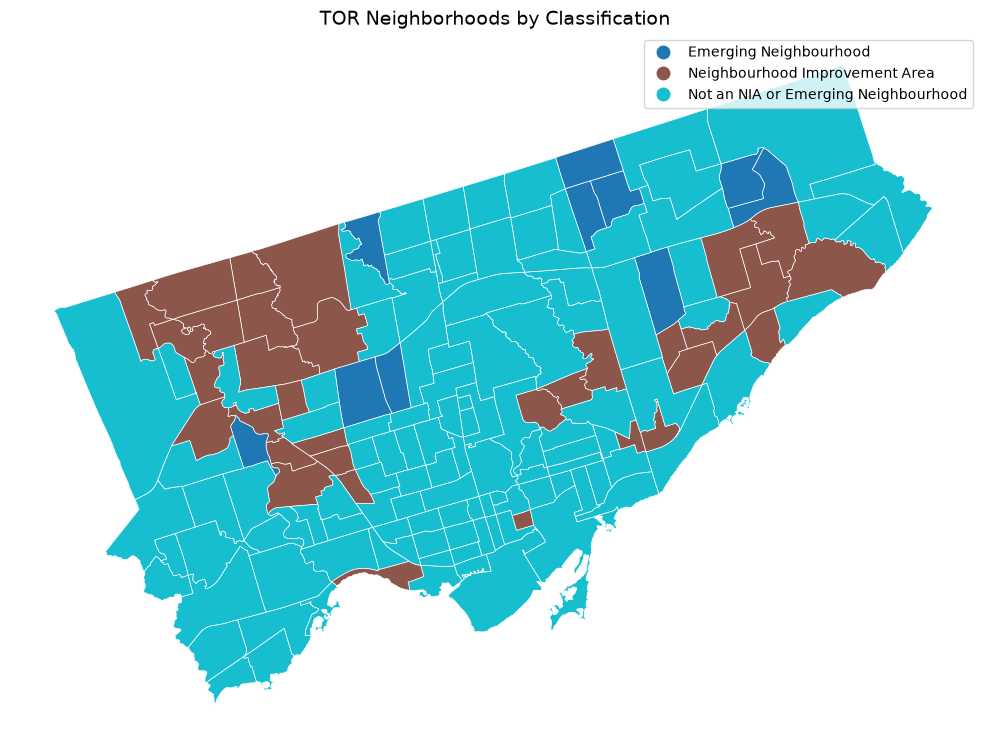

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

neigh.plot(
    ax=ax,
    column='CLASSIFICATION',
    legend=True,
    edgecolor='white',
    linewidth=0.5,
)

ax.set_title('TOR Neighborhoods by Classification', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Plot a Sample of Trees

Plotting ~1.2M points is slow, so we take a random sample of 5,000
and overlay them on the neighborhood boundaries.

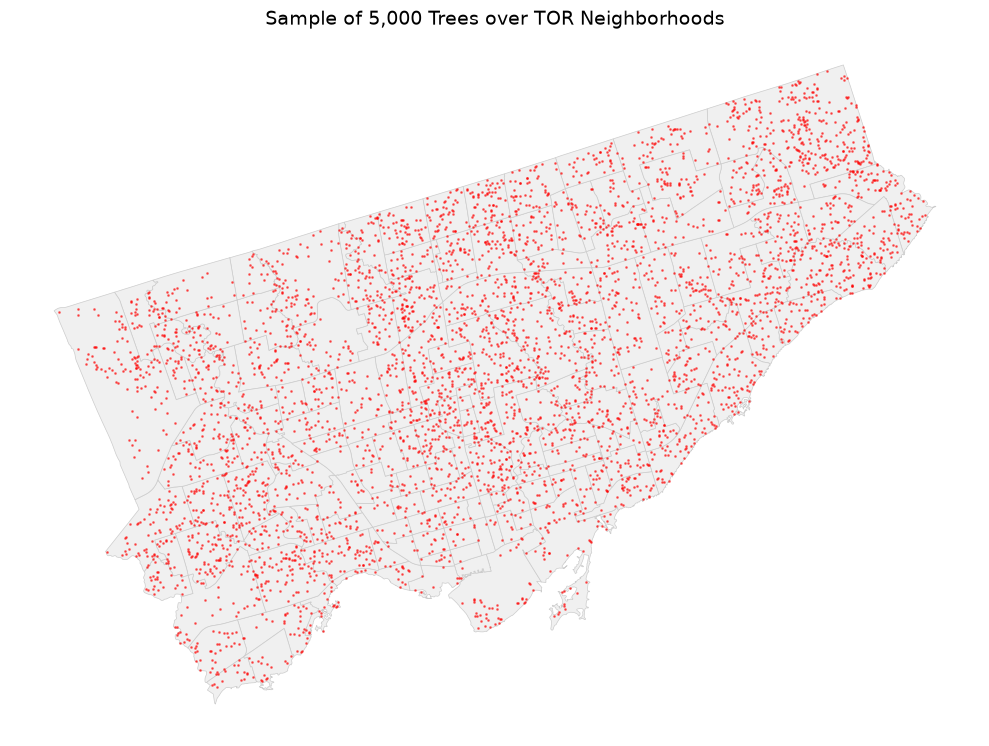

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Draw neighborhood outlines as the basemap
neigh.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)

# Overlay a sample of hydrants
trees.sample(5000, random_state=42).plot(
    ax=ax,
    color='red',
    markersize=1,
    alpha=0.5,
)

ax.set_title('Sample of 5,000 Trees over TOR Neighborhoods', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 7. Spatial Join — Count Trees per Neighborhood

This is the core spatial analysis: for each tree, find which neighborhood it falls in.
We use `sjoin` (spatial join) with `predicate='within'`.

This may take 30–60 seconds on ~1.2M points against ~150 polygons.

In [11]:
# Spatial join: tag each tree with the neighborhood it falls within
trees_with_n = gpd.sjoin(
    trees,
    neigh.drop(columns=['CLASSIFICATION']),
    how='inner',
    predicate='within',
)

print(f"Trees matched to a neighborhood: {len(trees_with_n):,}")
print(f"Trees NOT matched (outside boundaries): {len(trees) - len(trees_with_n):,}")
trees_with_n.head()

Trees matched to a neighborhood: 1,249,624
Trees NOT matched (outside boundaries): 41


,geometry,index_right,AREA_NAME
0,POINT (-79.42382 43.70328),55,Forest Hill North
1,POINT (-79.42315 43.70316),55,Forest Hill North
2,POINT (-79.26191 43.76492),6,Bendale-Glen Andrew
3,POINT (-79.26207 43.76523),6,Bendale-Glen Andrew
4,POINT (-79.26254 43.76567),6,Bendale-Glen Andrew


## 8. Tree Counts by Neighborhood

Group by neighborhood name, count, and sort to find the most tree-dense areas.

In [12]:
tree_counts = (
    trees_with_n
    .groupby(['AREA_NAME'])
    .size()
    .reset_index(name='tree_count')
    .sort_values('tree_count', ascending=False)
)

print("Top 10 neighborhoods by tree count:")
print(tree_counts.head(10).to_string(index=False))

print(f"\nTotal neighborhoods with trees: {len(tree_counts)}")

Top 10 neighborhoods by tree count:
                        AREA_NAME  tree_count
              Morningside Heights       67512
           West Humber-Clairville       28538
Bridle Path-Sunnybrook-York Mills       26897
                        West Hill       25268
                       West Rouge       23646
                Banbury-Don Mills       23442
             St.Andrew-Windfields       18471
                       Cliffcrest       18212
              Stonegate-Queensway       18044
          York University Heights       17239

Total neighborhoods with trees: 158


## 9. Choropleth Map — Trees by Neighborhood

Merge the counts back to the neighborhood polygons and visualize.

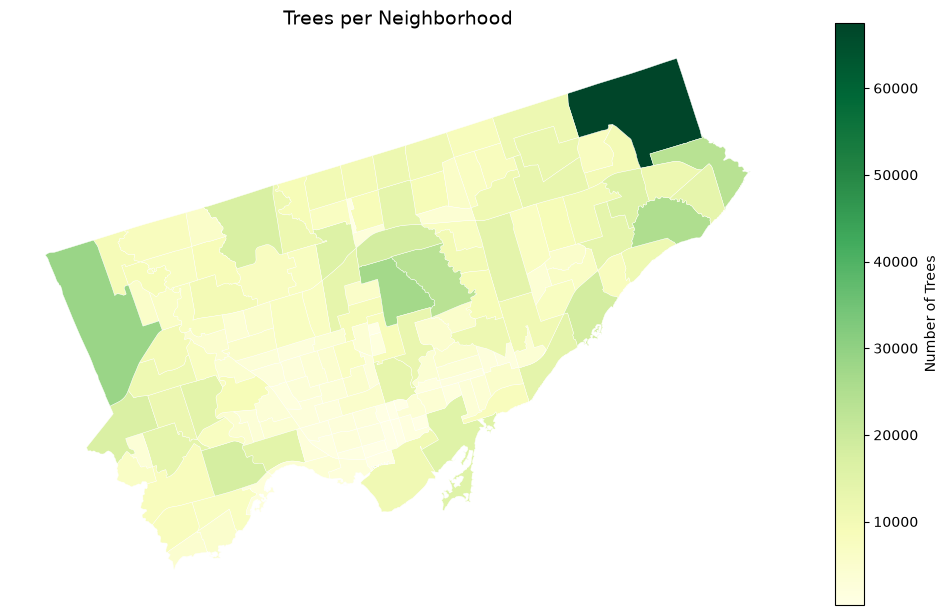

<Figure size 640x480 with 0 Axes>

In [37]:
# Merge counts onto the neighborhood geometries
neigh_with_counts = neigh.merge(
    tree_counts[['AREA_NAME', 'tree_count']],
    on='AREA_NAME',
    how='left',
)

# Fill neighborhoods with no trees as 0
neigh_with_counts['tree_count'] = (
    neigh_with_counts['tree_count'].fillna(0).astype(int)
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

neigh_with_counts.plot(
    ax=ax,
    column='tree_count',
    cmap='YlGn',
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Number of Trees', 'shrink': 0.6},
)

ax.set_title('Trees per Neighborhood', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.savefig('./images/1-tree_count.png')

## 10. Calculate Tree Density (per km²)

Raw counts are misleading — large neighborhoods naturally have more trees.
We reproject to a meter-based CRS (EPSG:26917) to calculate area, then compute density.

In [38]:
# Reproject to Web Mercator for area calculation in meters
neigh_projected = neigh_with_counts.to_crs(epsg=26917)

# Calculate area in square kilometers
neigh_with_counts['area_km2'] = ( 
    neigh_projected.geometry.area / 1_000_000
).round(2)

# Trees per square kilometer
neigh_with_counts['trees_per_km2'] = (
    neigh_with_counts['tree_count'] / neigh_with_counts['area_km2']
).round(2)

# Top 5 densest neighborhoods
densest = neigh_with_counts.nlargest(5, 'trees_per_km2')
print("Top 5 neighborhoods by tree density (per km²):")
print(densest[['AREA_NAME', 'tree_count', 'area_km2', 'trees_per_km2']]
      .to_string(index=False))

print()

# Bottom 5 not-densest neighborhoods
densest = neigh_with_counts.nsmallest(5, 'trees_per_km2')
print("Bottom 5 neighborhoods by tree density (per km²):")
print(densest[['AREA_NAME', 'tree_count', 'area_km2', 'trees_per_km2']]
      .sort_values('trees_per_km2', ascending=False)
      .to_string(index=False))

Top 5 neighborhoods by tree density (per km²):
                        AREA_NAME  tree_count  area_km2  trees_per_km2
Bridle Path-Sunnybrook-York Mills       26897      8.84        3042.65
                 Lansing-Westgate       16018      5.35        2994.02
                        Guildwood       11293      3.81        2964.04
              Rosedale-Moore Park       13679      4.66        2935.41
              Lawrence Park South        9364      3.24        2890.12

Bottom 5 neighborhoods by tree density (per km²):
             AREA_NAME  tree_count  area_km2  trees_per_km2
 Etobicoke City Centre        8116     10.13         801.18
   Downtown Yonge East         539      0.81         665.43
Harbourfront-CityPlace         673      1.14         590.35
      Wellington Place         448      0.98         457.14
    Yonge-Bay Corridor         378      1.12         337.50


In [39]:
print("Median tree density (per km²)")
print(neigh_with_counts["trees_per_km2"].median().round(2))
print()
print("Mean tree density (per km²):")
print(neigh_with_counts["trees_per_km2"].mean().round(2))

Median tree density (per km²)
2008.24

Mean tree density (per km²):
1951.75


## 11. Choropleth Map — Trees Density

Visualize the normalized tree count by neighborhood area.

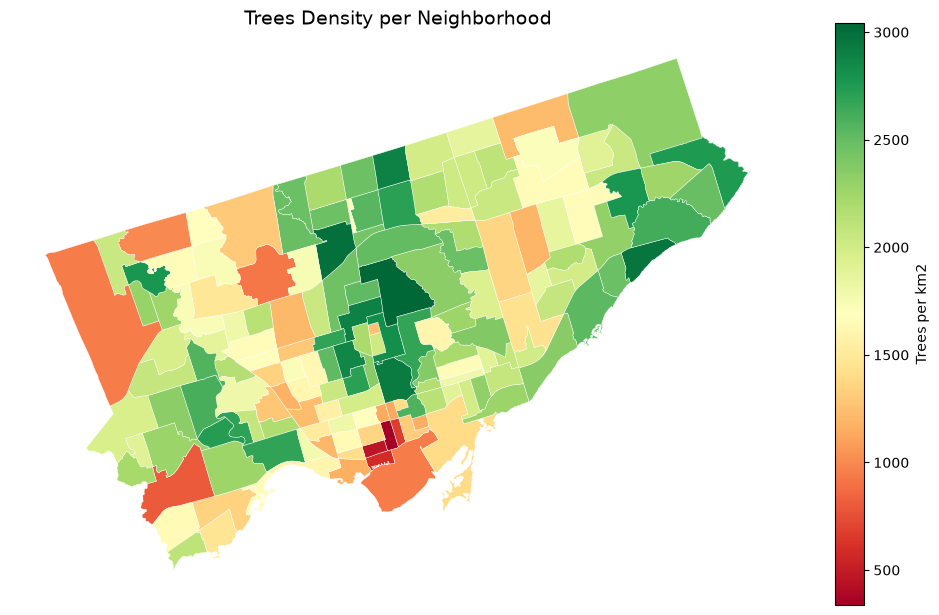

<Figure size 640x480 with 0 Axes>

In [40]:
# set the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

neigh_with_counts.plot(
    ax=ax,
    column='trees_per_km2',
    cmap='RdYlGn',
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Trees per km2', 'shrink': 0.6},
)

ax.set_title('Trees Density per Neighborhood', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.savefig('./images/2-tree_density.png')

## 11. Calculate Tree Coveraga percentage

Coverage analysis leads to a deeper finding by aggregating buffer areas of 100 m from each tree. 
We reproject to a meter-based CRS (EPSG:26917) to calculate area, then compute density.

In [41]:
# Reproject to a meter based local crs
tree_utm = trees_with_n.to_crs(epsg=26917)

# Calculate 100m buffers for each tree
tree_utm["geometry"] = tree_utm.geometry.buffer(100)

# Keep only the buffer part that fits into its neighborhood
## Dissolve buffers into a single one per neighborhood
tree_group = tree_utm.dissolve(by="AREA_NAME", sort=True, as_index=True)

##   Align by AREA_NAME
neigh_proj = neigh_projected.set_index("AREA_NAME").loc[tree_group.index]

##   Clip each buffer with its matching neighborhood
tree_group["geometry"] = tree_group.geometry.intersection(
    neigh_proj.geometry
)

##   reset index
tree_group = tree_group.reset_index()

# Calc the clipped buffer area
tree_group["tree_coverage_km2"] = (tree_group.geometry.area / 1000000).round(2)

# Add tree coverage
neigh_with_coverage = (
    neigh_with_counts.merge(
        tree_group.drop(columns = ['geometry']), on="AREA_NAME", how="inner" 
    )
)

# Calc tree coverage percentage
neigh_with_coverage['coverage_percentage'] = (
    100 * neigh_with_coverage['tree_coverage_km2'] / neigh_with_coverage['area_km2']
).round(2)

In [42]:
# Top 5 covered neighborhoods
densest = neigh_with_coverage.nlargest(5, 'coverage_percentage')
print("Top 5 neighborhoods by tree coverage (percentage):")
print(densest[["AREA_NAME", "area_km2", "tree_coverage_km2", "coverage_percentage"]]
      .to_string(index=False))

print()

# Bottom 5 covered neighborhoods
densest = neigh_with_coverage.nsmallest(5, 'coverage_percentage')
print("Bottom 5 neighborhoods by tree coverage (percentage):")
print(densest[["AREA_NAME", "area_km2", "tree_coverage_km2", "coverage_percentage"]]
      .sort_values('coverage_percentage', ascending=False)
      .to_string(index=False))

Top 5 neighborhoods by tree coverage (percentage):
                AREA_NAME  area_km2  tree_coverage_km2  coverage_percentage
South Eglinton-Davisville      0.94               0.94                100.0
            North Toronto      0.40               0.40                100.0
       Dovercourt Village      1.50               1.50                100.0
 Junction-Wallace Emerson      2.22               2.22                100.0
                 Avondale      1.03               1.03                100.0

Bottom 5 neighborhoods by tree coverage (percentage):
                            AREA_NAME  area_km2  tree_coverage_km2  coverage_percentage
                  Downtown Yonge East      0.81               0.73                90.12
                      Agincourt North      7.26               6.49                89.39
                   Yonge-Bay Corridor      1.12               0.93                83.04
                            Downsview      8.28               6.34                76.5

In [43]:
print("Median tree coverage (percentage)")
print(neigh_with_coverage["coverage_percentage"].median().round(2))
print()
print("Mean tree coverage (percentage)")
print(neigh_with_coverage["coverage_percentage"].mean().round(2))

Median tree coverage (percentage)
99.84

Mean tree coverage (percentage)
98.6


## 12. Choropleth Map — Trees Coverage

Visualize the tree coverage percentage.

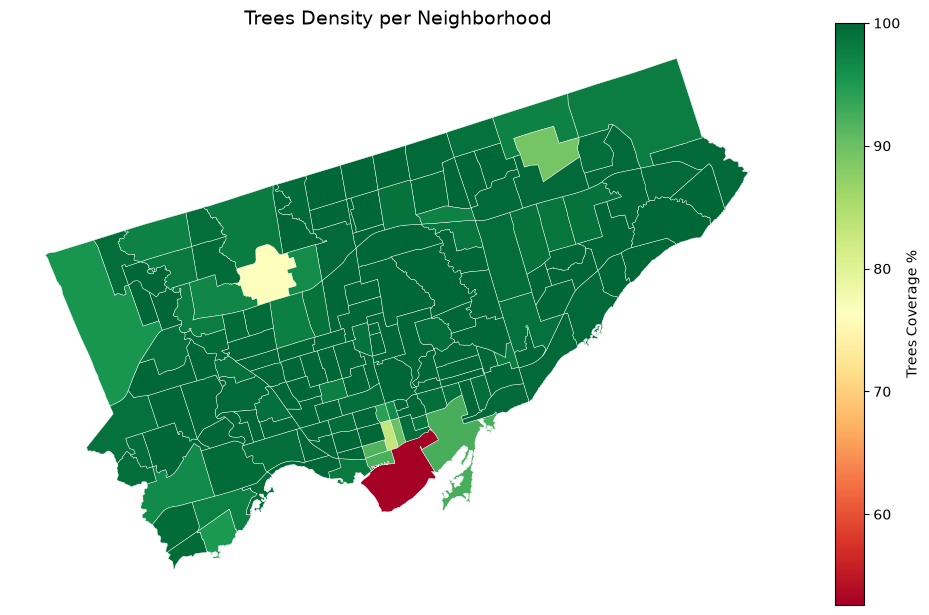

<Figure size 640x480 with 0 Axes>

In [44]:
# set the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

neigh_with_coverage.plot(
    ax=ax,
    column='coverage_percentage',
    cmap='RdYlGn',
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Trees Coverage %', 'shrink': 0.6},
)

ax.set_title('Trees Density per Neighborhood', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.savefig('./images/3-tree_coverage.png')

## 12. Export Results to GeoParquet

GeoParquet is a modern, efficient format for geospatial data — much faster to read
than Shapefiles or GeoJSON, and it preserves CRS metadata.

In [45]:
# clean dataframe
neigh_with_results = (
    neigh_with_coverage[
        ["AREA_NAME", "tree_count", "area_km2", "trees_per_km2","tree_coverage_km2", "coverage_percentage","geometry"]]
)

In [46]:
output_path = './data/processed/tor_neighborhood_tree_coverage.parquet'

neigh_with_results.to_parquet(output_path)

# Verify the export by reading it back
result = gpd.read_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"Shape: {result.shape}")
print(f"CRS:   {result.crs}")
print(f"Columns: {list(result.columns)}")

Exported to: ./data/processed/tor_neighborhood_tree_coverage.parquet
Shape: (158, 7)
CRS:   {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longi

## Summary

In this notebook you:

1. Loaded two GeoJSON datasets into GeoDataFrames
2. Explored geometry types, CRS, and column structures
3. Plotted neighborhoods and trees with matplotlib
4. Performed a spatial join to count trees per neighborhood
5. Calculated area-normalized tree density
6. Plotted neighborhoods and tree density with matplotlib
7. Calculated tree coverage percentage
8. Plotted neighborhoods and tree coverage with matplotlib
9. Exported the results to GeoParquet

These same patterns — load, explore, spatial join, aggregate, export — apply to
almost any point-in-polygon analysis.